### **GRAD - CAM**

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import timm
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

binary_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=2
)

binary_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_binary_best.pth"
))

binary_model_swin = binary_model_swin.to(device)
binary_model_swin.eval()


multi_model_swin = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=4
)

multi_model_swin.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/swin_multiclass_best.pth"
))

multi_model_swin = multi_model_swin.to(device)
multi_model_swin.eval()


print("Binary and Multi-class models loaded successfully!")

Binary and Multi-class models loaded successfully!


In [ ]:
import torch
import torchvision.models as models

efficientnet_model = models.efficientnet_b0()

efficientnet_model.classifier[1] = torch.nn.Linear(
    efficientnet_model.classifier[1].in_features, 4
)

efficientnet_model.load_state_dict(torch.load(
    "/content/drive/MyDrive/EarProject/models/efficientnet_b0_multiclass_best.pth"
))

efficientnet_model = efficientnet_model.to(device)
efficientnet_model.eval()

print("EfficientNet loaded successfully!")

EfficientNet loaded successfully!


In [ ]:
from PIL import Image
import torch
from torchvision import transforms

binary_classes = ['Abnormal', 'Normal']

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 121.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3e28bb0b41e77ac3b2e1fc832d5dfb9532d4cbc2c693cc1952bf5ee9871c0f57
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

In [ ]:
target_layer = efficientnet_model.features[-1]

In [ ]:
def apply_gradcam_effnet(image, input_tensor):
    cam = GradCAM(model=efficientnet_model, target_layers=[target_layer])

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    image_np = np.array(image.resize((224, 224))) / 255.0

    cam_image = show_cam_on_image(
        image_np.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return cam_image

In [ ]:
multi_classes = [
    "Acute Otitis Media",
    "Chronic Otitis Media",
    "Myringosclerosis",
    "Cochlear Implant"
]

def predict_pipeline_final(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Binary
    with torch.no_grad():
        binary_out = binary_model_swin(input_tensor)
        binary_prob = torch.softmax(binary_out, dim=1)
        b_conf, b_pred = torch.max(binary_prob, 1)

    binary_label = binary_classes[b_pred.item()]

    if binary_label == 'Normal':
        return {
            "image": image,
            "stage": "normal",
            "binary_conf": b_conf.item()
        }

    # Multi-class
    with torch.no_grad():
        multi_out = multi_model_swin(input_tensor)
        multi_prob = torch.softmax(multi_out, dim=1)
        m_conf, m_pred = torch.max(multi_prob, 1)

    disease = multi_classes[m_pred.item()]

    cam_image = apply_gradcam_effnet(image, input_tensor)

    return {
        "image": image,
        "stage": "abnormal",
        "binary_conf": b_conf.item(),
        "disease": disease,
        "disease_conf": m_conf.item(),
        "gradcam": cam_image
    }

Abnormal (0.99)
Disease: Acute Otitis Media (0.95)


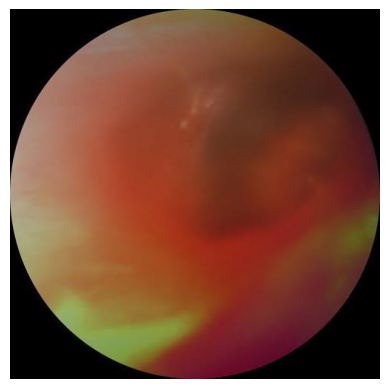

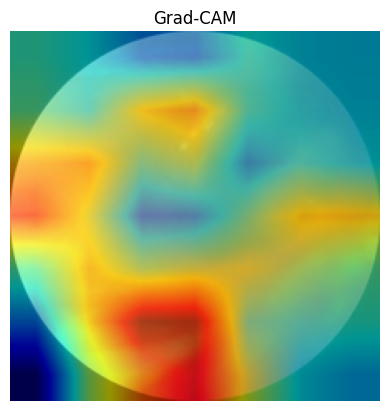

In [ ]:
result = predict_pipeline_final("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/aom-274-_jpg.rf.3f53f6f5794c4e9876c63143d675bae5.jpg")

import matplotlib.pyplot as plt

plt.imshow(result["image"])
plt.axis('off')

if result["stage"] == "normal":
    print(f"Normal Ear ({result['binary_conf']:.2f})")

else:
    print(f"Abnormal ({result['binary_conf']:.2f})")
    print(f"Disease: {result['disease']} ({result['disease_conf']:.2f})")

    plt.figure()
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM")
    plt.axis('off')

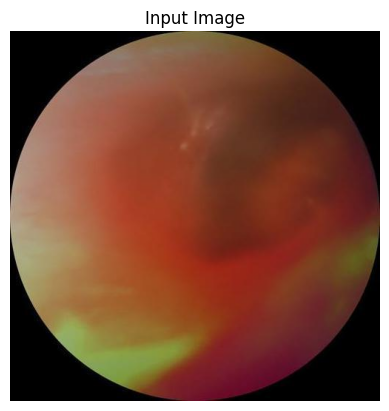

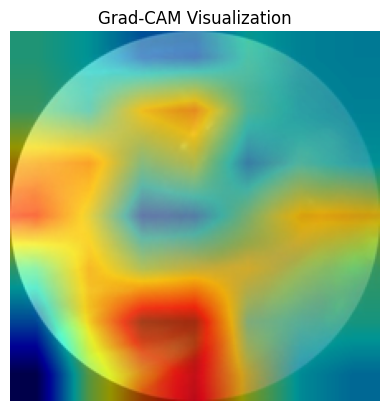


PREDICTION RESULT
Abnormal Detected
Confidence: 0.99
Disease: Acute Otitis Media
Disease Confidence: 0.95

------------------------
DISEASE DETAILS
------------------------
Middle ear infection with fluid buildup.


In [ ]:
from IPython.display import display

result = predict_pipeline_final("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/aom-274-_jpg.rf.3f53f6f5794c4e9876c63143d675bae5.jpg")

import matplotlib.pyplot as plt

plt.imshow(result["image"])
plt.title("Input Image")
plt.axis('off')
display(plt.gcf())
plt.close()

# Normal case
if result["stage"] == "normal":
    print(f"Normal Ear")
    print(f"Confidence: {result['binary_conf']:.2f}")

# Abnormal case
else:
    fig = plt.figure()
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM Visualization")
    plt.axis('off')
    display(fig)
    plt.close()

    print("\n========================")
    print("PREDICTION RESULT")
    print("========================")

    print(f"Abnormal Detected")
    print(f"Confidence: {result['binary_conf']:.2f}")
    print(f"Disease: {result['disease']}")
    print(f"Disease Confidence: {result['disease_conf']:.2f}")

    print("\n------------------------")
    print("DISEASE DETAILS")
    print("------------------------")

    if result["disease"] == "Acute Otitis Media":
        print("Middle ear infection with fluid buildup.")
    elif result["disease"] == "Chronic Otitis Media":
        print("Long-term infection with possible damage.")
    elif result["disease"] == "Myringosclerosis":
        print("Scarring of the eardrum.")
    elif result["disease"] == "Cochlear Implant":
        print("Presence of hearing implant device.")

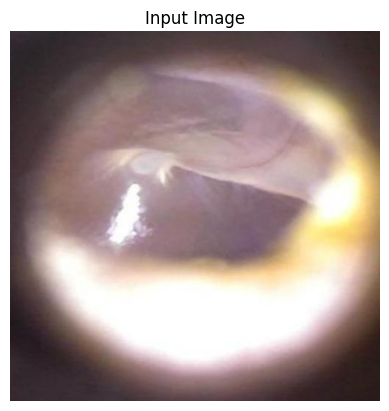

Normal Ear
Confidence: 0.98


In [ ]:
from IPython.display import display

result = predict_pipeline_final("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/norm-99-_jpg.rf.220b09fd0dcdf972cfa52a1bde6b5d05.jpg")

import matplotlib.pyplot as plt

plt.imshow(result["image"])
plt.title("Input Image")
plt.axis('off')
display(plt.gcf())
plt.close()

# Normal case
if result["stage"] == "normal":
    print(f"Normal Ear")
    print(f"Confidence: {result['binary_conf']:.2f}")

# Abnormal case
else:
    fig = plt.figure()
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM Visualization")
    plt.axis('off')
    display(fig)
    plt.close()

    print("\n========================")
    print("PREDICTION RESULT")
    print("========================")

    print(f"Abnormal Detected")
    print(f"Confidence: {result['binary_conf']:.2f}")
    print(f"Disease: {result['disease']}")
    print(f"Disease Confidence: {result['disease_conf']:.2f}")

    print("\n------------------------")
    print("DISEASE DETAILS")
    print("------------------------")

    if result["disease"] == "Acute Otitis Media":
        print("Middle ear infection with fluid buildup.")
    elif result["disease"] == "Chronic Otitis Media":
        print("Long-term infection with possible damage.")
    elif result["disease"] == "Myringosclerosis":
        print("Scarring of the eardrum.")
    elif result["disease"] == "Cochlear Implant":
        print("Presence of hearing implant device.")

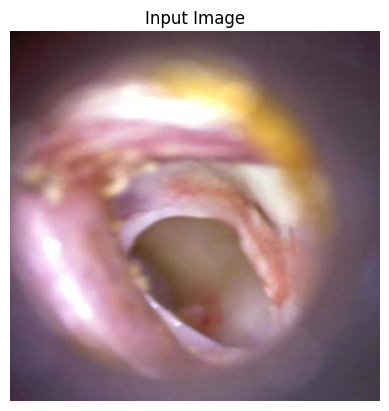

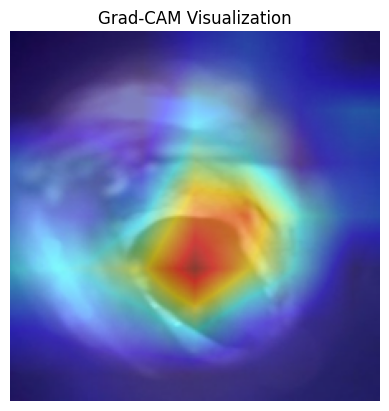


PREDICTION RESULT
Abnormal Detected
Confidence: 0.98
Disease: Myringosclerosis
Disease Confidence: 0.99

------------------------
DISEASE DETAILS
------------------------
Scarring of the eardrum.


In [ ]:
from IPython.display import display

result = predict_pipeline_final("/content/drive/MyDrive/Ear Diseases/Dataset/extracted/test/com-100-_jpg.rf.1c15654d79baed730148a23969efe6bd.jpg")

import matplotlib.pyplot as plt

plt.imshow(result["image"])
plt.title("Input Image")
plt.axis('off')
display(plt.gcf())
plt.close()

# Normal case
if result["stage"] == "normal":
    print(f"Normal Ear")
    print(f"Confidence: {result['binary_conf']:.2f}")

# Abnormal case
else:
    fig = plt.figure()
    plt.imshow(result["gradcam"])
    plt.title("Grad-CAM Visualization")
    plt.axis('off')
    display(fig)
    plt.close()

    print("\n========================")
    print("PREDICTION RESULT")
    print("========================")

    print(f"Abnormal Detected")
    print(f"Confidence: {result['binary_conf']:.2f}")
    print(f"Disease: {result['disease']}")
    print(f"Disease Confidence: {result['disease_conf']:.2f}")

    print("\n------------------------")
    print("DISEASE DETAILS")
    print("------------------------")

    if result["disease"] == "Acute Otitis Media":
        print("Middle ear infection with fluid buildup.")
    elif result["disease"] == "Chronic Otitis Media":
        print("Long-term infection with possible damage.")
    elif result["disease"] == "Myringosclerosis":
        print("Scarring of the eardrum.")
    elif result["disease"] == "Cochlear Implant":
        print("Presence of hearing implant device.")